In [1]:
import numpy as np
import json
from typing import List, Dict
import os
import subprocess
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import normalize

In [25]:
import numpy as np
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import normalize
from functools import lru_cache

@lru_cache(maxsize=None)
def _truncated_zipf_pmf(card: int, a: float) -> np.ndarray:
    """
    P(k) ∝ 1 / k^a  for k=1..card, normalized.
    a>0에서 유한 card에 대해 항상 정상화 가능.
    """
    k = np.arange(1, card + 1, dtype=np.float64)
    p = 1.0 / np.power(k, a)
    p /= p.sum()
    return p.astype(np.float64)

def _sample_labels(rng, distribution, card, size, zipf_param):
    """
    distribution == 'zipf'일 때, 1..card 범위의 truncated-zipf를 직접 샘플링.
    → tail을 card에 clip하지 않으므로 최대값 스파이크 없음.
    """
    if distribution == 'zipf':
        p = _truncated_zipf_pmf(card, float(zipf_param))
        return rng.choice(np.arange(1, card + 1, dtype=np.int32), size=size, p=p)
    elif distribution in ('uniform', 'random'):
        return rng.integers(1, card + 1, size=size, dtype=np.int32)
    else:
        raise ValueError(f"unsupported distribution: {distribution}")

def _permute_by_correlation_keep_multiset(
    rng,
    labels,            # (N,) int32, includes -1 for missing; will be copied
    present_mask,      # (N,) bool
    cluster_ids,       # (N,) int
    corr               # float in [0,1]
):
    """
    전역 라벨 멀티셋(값/개수)은 유지하되, present인 인덱스들만 대상으로
    '누가 어떤 라벨을 가질지'를 재배치한다.
    - 클러스터 정렬: present에서 큰 클러스터일수록 앞쪽으로 배치
    - 라벨 정렬: present 라벨 중 빈도(내림차순) 큰 값부터 블록 배치
    - corr↑일수록 (클러스터 배치와 라벨 블록) 정렬을 더 강하게 반영
    """
    if corr <= 0:
        return labels

    out = labels.copy()

    idx_present = np.flatnonzero(present_mask)
    if idx_present.size == 0:
        return out

    # 1) present 라벨 멀티셋 확보
    present_labels = labels[idx_present]

    # 2) 클러스터 크기 기반 정렬 키 만들기
    cl = cluster_ids[idx_present]
    uniq_cl, inv_cl = np.unique(cl, return_inverse=True)

    # 각 클러스터의 present 샘플 수
    counts_cl = np.bincount(inv_cl, minlength=uniq_cl.size)
    # 큰 클러스터 먼저
    order_cl_by_size = np.argsort(-counts_cl, kind='mergesort')
    # 클러스터ID -> size-rank 매핑
    rank_table = np.empty_like(order_cl_by_size)
    rank_table[order_cl_by_size] = np.arange(order_cl_by_size.size)
    cl_size_rank = rank_table[inv_cl].astype(np.float32)
    denom = max(order_cl_by_size.size, 1)
    cl_rank_norm = cl_size_rank / denom

    # 3) 라벨 멀티셋을 "빈도 내림차순(+값 오름차순)" 블록으로 정렬
    uniq_lab, counts_lab = np.unique(present_labels, return_counts=True)
    order_lab = np.lexsort((uniq_lab, -counts_lab))  # (-count, value)
    lab_vals_sorted = uniq_lab[order_lab]
    lab_cnts_sorted = counts_lab[order_lab]
    labels_sorted = np.repeat(lab_vals_sorted, lab_cnts_sorted)

    # 4) corr로 클러스터 정렬과 랜덤 혼합
    noise = rng.random(idx_present.size, dtype=np.float32)
    blended = (1.0 - corr) * noise + corr * (cl_rank_norm + 1e-6 * noise)

    order_idx = np.argsort(blended, kind='mergesort')
    target_indices = idx_present[order_idx]

    # 5) 재배치
    out[target_indices] = labels_sorted
    return out

def generate_attribute_payloads(
    num_vectors,
    num_attributes,
    cardinalities,
    base_vectors=None,
    correlations=None,   # [0, 1] 범위
    distribution='zipf',
    zipf_param=1.5,
    missing_prob=[0.5,0.5,0.5],
    missing_value=-1,
    seed=42,
):
    """
    절차:
    1) 각 attribute에 대해 전역 분포(distribution)로 raw 라벨 생성 + missing 적용 → payload 채움
    2) '모든 attribute가 missing'인 행을 먼저 보정 (전역 분포 유지)
    3) 각 attribute별로, cardinality 개수만큼 클러스터링(K=card) 수행
    4) 라벨 멀티셋은 그대로 보존하면서, corr에 비례해 '누가 어떤 라벨을 받는지'만 재배치
    """
    assert len(cardinalities) == num_attributes, "카디널리티 길이가 attribute 수와 일치해야 합니다."
    rng_root = np.random.default_rng(seed)

    # ----------- 입력 벡터 준비 -----------
    if base_vectors is None:
        base_vectors = rng_root.normal(size=(num_vectors, 16)).astype(np.float32)
    X = normalize(base_vectors.astype(np.float32))

    # ----------- 1) raw 생성(전역 분포) + missing 적용 -----------
    payloads = np.full((num_vectors, num_attributes), missing_value, dtype=np.int32)
    present_masks = np.zeros((num_vectors, num_attributes), dtype=bool)

    for a in range(num_attributes):
        rng = np.random.default_rng(seed + 1000 + a)
        card = cardinalities[a]
        # 전역 분포로 라벨 생성 (truncated Zipf)
        raw = _sample_labels(rng, distribution, card, size=num_vectors, zipf_param=zipf_param)
        # missing 적용
        present = (rng.random(num_vectors) > missing_prob[a])
        payloads[present, a] = raw[present]
        present_masks[:, a] = present

    # ----------- 2) 모든 attribute가 missing인 행 보정 -----------
    all_missing = np.all(~present_masks, axis=1)
    if np.any(all_missing):
        rows = np.flatnonzero(all_missing)
        cols = rng_root.integers(0, num_attributes, size=rows.size)
        for r, c in zip(rows, cols):
            rng = np.random.default_rng(seed + 2000 + c)
            card = cardinalities[c]
            val = _sample_labels(rng, distribution, card, size=1, zipf_param=zipf_param)[0]
            payloads[r, c] = val
            present_masks[r, c] = True

    # ----------- 3) corr 반영: 멀티셋 보존 재배치 -----------
    if correlations is None:
        correlations = np.zeros(num_attributes, dtype=np.float32)

    for a in range(num_attributes):
        corr = float(correlations[a])
        if corr <= 0:
            continue

        card = cardinalities[a]
        rng = np.random.default_rng(seed + 3000 + a)

        # (a) 이 attribute 전용 클러스터링: K=card
        km = MiniBatchKMeans(
            n_clusters=card,
            random_state=seed + 4000 + a,
            batch_size=10000
        )
        cluster_ids = km.fit_predict(X)

        # (b) 멀티셋 보존 재배치(결측 제외)
        col = payloads[:, a]
        present_mask = (col != missing_value)
        col_new = _permute_by_correlation_keep_multiset(
            rng=rng,
            labels=col,
            present_mask=present_mask,
            cluster_ids=cluster_ids,
            corr=corr
        )
        payloads[:, a] = col_new

    return payloads


In [26]:





def payloads_to_dicts(payloads, prefix="label", include_missing=True):
    """
    Convert attribute payloads to list of dicts.

    Args:
        payloads (np.ndarray): (N, A) array of attribute values
        prefix (str): key prefix (default: "label")
        include_missing (bool): whether to include -1 in output dicts

    Returns:
        List[Dict[str, int]]
    """
    num_vectors, num_attributes = payloads.shape
    dict_list = []

    for i in range(num_vectors):
        d = {}
        for j in range(num_attributes):
            val = payloads[i, j]
            if include_missing or val != -1:
                d[f"{prefix}_{j+1}"] = int(val)
        dict_list.append(d)
    return dict_list

def build_label_mapping(filter_dict: dict, mapping_json_path: str):
    """
    filters.json 안의 각 entry(name) 아래 values 문자열에 대해
    (name, value) 쌍별로 0부터 시작하는 고유 ID를 매핑하고,
    매핑 결과를 JSON 파일로 저장합니다.
    """
    # 1) filters.json 로드
    
    filters = filter_dict

    mapping = {}
    next_id = 1

    # 2) (name, value) 쌍별로 ID 할당
    for temp in filters:
        for key, value in temp.items():
            if (key, value) not in mapping:
                mapping[(key, value)] = next_id
                next_id += 1
            
    # 3) 문자열 키로 변환
    str_mapping = { f"{name}:{val}": idx for (name, val), idx in mapping.items() }

    # 4) 매핑을 JSON 파일로 저장
    with open(mapping_json_path, 'w', encoding='utf-8') as out:
        json.dump(str_mapping, out, ensure_ascii=False, indent=2)

    print(f"Saved {len(str_mapping)} mappings to '{mapping_json_path}'. Max ID = {next_id - 1}")
    return mapping_json_path



def save_vector_label(
    vector_payload: List[Dict],
    mapping_json_path: str,
    output_txt_path: str
):
    """
    - payload_jsonl_path: JSONL 파일 경로, 각 줄이 {"label_1": 1, ...} 형태
    - mapping_json_path: "label:value" → id 매핑이 들어 있는 JSON 경로
    - output_txt_path: 결과를 저장할 .txt 경로

    결과는 각 payload를 ID로 매핑해서 콤마로 연결, 한 줄씩 저장.
    """
    # 매핑 로드
    with open(mapping_json_path, 'r', encoding='utf-8') as f:
        mapping = json.load(f)

    with open(output_txt_path, 'w', encoding='utf-8') as fout:
        for i, payload in enumerate(vector_payload):
            ids = []
            for key, value in payload.items():
                map_key = f"{key}:{value}"
                if map_key not in mapping:
                    raise ValueError(f"[Line {i}] mapping.json에 {map_key}이 없습니다.")
                ids.append(str(mapping[map_key]))
            fout.write(','.join(ids) + '\n')

    print(f"[✓] 라벨 텍스트 저장 완료: {output_txt_path}")


def read_fvecs(path):
    a = np.fromfile(path, dtype=np.int32)
    dim = a[0]
    if (a.size % (dim + 1)) != 0:
        raise RuntimeError("fvecs file corrupted or wrong dimension")
    return a.reshape(-1, dim + 1)[:, 1:].view('float32')


def save_compute_groundtruth(
    base_label_file,
    query_label_file,
    gt_file,
    query_bin_file,
    base_bin_file,
    build_dir = "/home/mintaek/hybrid_index/methods/Unified-Navigating-Graph/build",
    data_type = "float",
    dist_fn = "L2",
    scenario = "containment",
    K = 10,
    num_threads = 200,
):
    cmd = [
        f"{build_dir}/tools/compute_groundtruth",
        "--data_type", str(data_type),
        "--dist_fn", str(dist_fn),
        "--scenario", str(scenario),
        "--K", str(K),
        "--num_threads", str(num_threads),
        "--base_bin_file", str(base_bin_file),
        "--base_label_file", str(base_label_file),
        "--query_bin_file", str(query_bin_file),
        "--query_label_file", str(query_label_file),
        "--gt_file", str(gt_file)
    ]
    print("[명령 실행] " + " \\\n    ".join(cmd))
    subprocess.run(cmd, check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

def load_groundtruth_bin(filename, nq):
    record_dtype = np.dtype([("idx", np.uint32), ("dist", np.float32)])
    file_size = os.path.getsize(filename)
    record_size = record_dtype.itemsize  # 8 bytes (4+4)
    total_recs = file_size // record_size

    if nq == 0 or total_recs % nq != 0:
        raise ValueError(f"GT file size mismatch: total_recs={total_recs}, nq={nq}")

    K_gt = total_recs // nq

    data = np.fromfile(filename, dtype=record_dtype, count=total_recs)
    # 인덱스만 추출, shape: (nq, K_gt)
    gt_indices = data["idx"].reshape(nq, K_gt)
    return gt_indices

In [27]:
dataset_name = "sift1m"
num_attribute = 7
cardinality = [6] * num_attribute
# cardinality = [3,2,2]
# base_distribution = "zipf"
base_distribution = "random"
query_distribution = "random"
base_missing_prob = 0.5
query_missing_prob = 0.5
original_data_path = f"/home/mintaek/hybrid_index/Benchmark/{dataset_name}_original"

In [28]:
base_vector_npy = read_fvecs(os.path.join(original_data_path, "sift_base.fvecs")) ## sift만 되게 해놨는데 수정해야함
query_vector_npy = read_fvecs(os.path.join(original_data_path, "sift_query.fvecs")) ## sift만 되게 해놨는데 수정해야함

In [29]:
print(type(base_vector_npy))
print(base_vector_npy.shape)

<class 'numpy.ndarray'>
(1000000, 128)


In [66]:
# attribute 3개, 각기 다른 상관도
corr = np.array([0, 0.5, 1])  
cards = [3, 6, 9]
missing_prob = [0.2,0.5,0.7]

payloads = generate_attribute_payloads(
    num_vectors=len(base_vector_npy),
    num_attributes=3,
    cardinalities=cards,
    base_vectors=base_vector_npy,
    correlations=corr,
    distribution="random",
    zipf_param=1.5,
    missing_prob=missing_prob,
    missing_value=-1
)
print(payloads)


[[ 3 -1  6]
 [ 2  4 -1]
 [ 1 -1 -1]
 ...
 [-1  1 -1]
 [-1  6 -1]
 [ 1  1 -1]]


In [67]:
payloads

array([[ 3, -1,  6],
       [ 2,  4, -1],
       [ 1, -1, -1],
       ...,
       [-1,  1, -1],
       [-1,  6, -1],
       [ 1,  1, -1]], shape=(1000000, 3), dtype=int32)

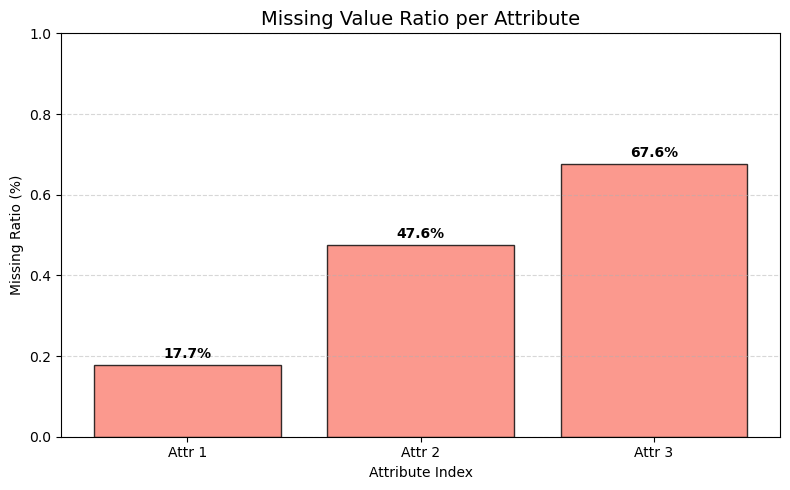

In [68]:
import numpy as np
import matplotlib.pyplot as plt

# payloads: shape = (N, num_attributes)
num_attributes = payloads.shape[1]

# 각 attribute별 missing 비율 계산
missing_ratios = []
for i in range(num_attributes):
    vals = payloads[:, i]
    missing_ratio = np.mean(vals == -1)  # (-1인 비율)
    missing_ratios.append(missing_ratio)

# 시각화
plt.figure(figsize=(8, 5))
bars = plt.bar(
    range(num_attributes),
    missing_ratios,
    color='salmon',
    edgecolor='black',
    alpha=0.8
)

# 값 표시
for i, bar in enumerate(bars):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f"{missing_ratios[i]*100:.1f}%",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.title("Missing Value Ratio per Attribute", fontsize=14)
plt.xlabel("Attribute Index")
plt.ylabel("Missing Ratio (%)")
plt.xticks(range(num_attributes), [f"Attr {i+1}" for i in range(num_attributes)])
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


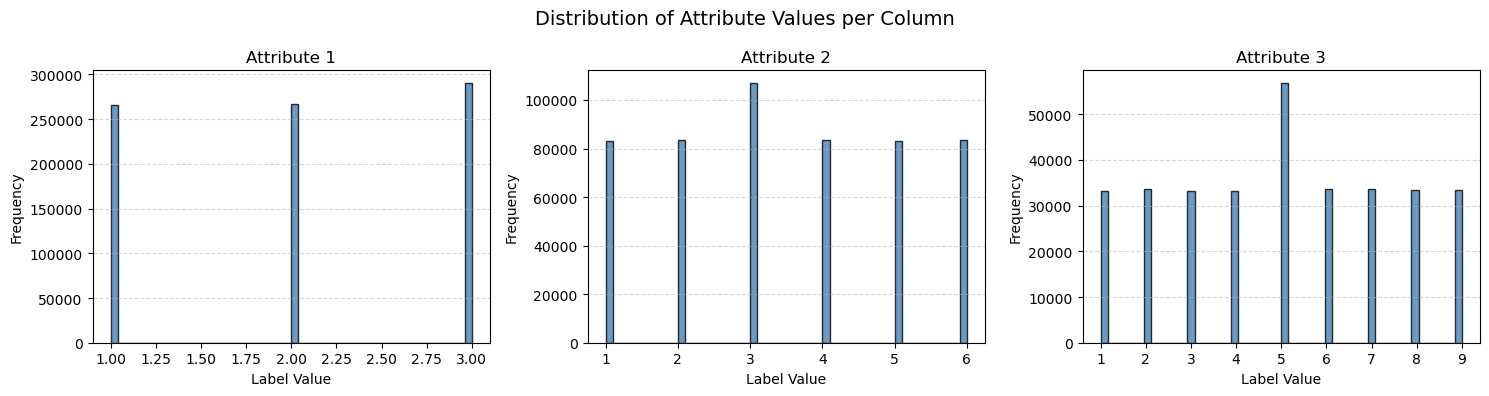

In [69]:
import numpy as np
import matplotlib.pyplot as plt

num_attributes = payloads.shape[1]

fig, axes = plt.subplots(1, num_attributes, figsize=(15, 4))

for i in range(num_attributes):
    ax = axes[i]
    vals = payloads[:, i]
    vals = vals[vals != -1]  # 결측(-1) 제거

    ax.hist(vals, bins=50, color='steelblue', edgecolor='black', alpha=0.8)
    ax.set_title(f"Attribute {i+1}")
    ax.set_xlabel("Label Value")
    ax.set_ylabel("Frequency")
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle("Distribution of Attribute Values per Column", fontsize=14)
plt.tight_layout()
plt.show()


In [70]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import normalized_mutual_info_score, homogeneity_score, completeness_score, adjusted_rand_score

def eval_corr_for_attribute(X, labels_col, card, seed=42, sample_for_plot=0, title_prefix="Attr"):
    """
    X: (N,D) base vectors
    labels_col: (N,) int, -1 = missing
    card: int, cardinality
    sample_for_plot: heatmap 행이 너무 크면 상위 n개 클러스터만 보여주고 싶을 때 0이 아니면 사용
    """
    # 0) 결측 제외
    present_mask = (labels_col != -1)
    if present_mask.sum() == 0:
        raise ValueError("No present labels.")
    Xp = X[present_mask]
    y  = labels_col[present_mask].astype(int)

    # 1) K=card로 클러스터
    km = MiniBatchKMeans(n_clusters=card, random_state=seed, batch_size=10000)
    cids = km.fit_predict(Xp)

    # 2) contingency (cluster x label)
    # 라벨 값이 1..card라고 가정. 혹은 np.unique로 재맵핑
    uniq_lab = np.unique(y)
    lab_to_idx = {lab:i for i,lab in enumerate(uniq_lab)}
    L = len(uniq_lab)
    C = card
    mat = np.zeros((C, L), dtype=np.int64)
    for ci, li in zip(cids, y):
        mat[ci, lab_to_idx[li]] += 1

    # purity (가중 평균)
    purity = (mat.max(axis=1).sum()) / mat.sum()

    # 정보이론 지표
    nmi  = normalized_mutual_info_score(y, cids)
    homo = homogeneity_score(y, cids)
    comp = completeness_score(y, cids)
    ari  = adjusted_rand_score(y, cids)

    metrics = dict(purity=purity, NMI=nmi, homogeneity=homo, completeness=comp, ARI=ari)

    # 3) 조건부 확률
    # P(same label)
    # (라벨 빈도 기반 계산: sum_k n_k*(n_k-1) / (N*(N-1)))
    nk = mat.sum(axis=0)
    N  = nk.sum()
    psame_label = ( (nk*(nk-1)).sum() ) / (N*(N-1) + 1e-12)
    # P(same label | same cluster)
    # = sum_c [sum_k n_ck*(n_ck-1) / sum_k n_ck*(sum_k n_ck -1)] * P(cluster=c)
    num = 0.0
    den = 0.0
    for c in range(C):
        nc = mat[c].sum()
        if nc <= 1: 
            continue
        num += ( (mat[c]*(mat[c]-1)).sum() ) / (nc*(nc-1))
        den += nc / N
    psame_label_given_cluster = num / (den + 1e-12)
    metrics["P(same_label)"] = psame_label
    metrics["P(same_label|same_cluster)"] = psame_label_given_cluster
    metrics["lift"] = psame_label_given_cluster / (psame_label + 1e-12)

    # 4) 히트맵 (row-normalized)
    row_sums = mat.sum(axis=1, keepdims=True).clip(min=1)
    mat_norm = mat / row_sums

    # 클러스터 크기 순으로 정렬하면 더 보기 좋음
    order = np.argsort(-row_sums.ravel())
    mat_show = mat_norm[order]

    if sample_for_plot and sample_for_plot < mat_show.shape[0]:
        mat_show = mat_show[:sample_for_plot]

    plt.figure(figsize=(min(12, 1.2*mat_show.shape[1]), 0.4*mat_show.shape[0] + 3))
    sns.heatmap(mat_show, cmap="viridis", cbar=True, vmin=0, vmax=1)
    plt.xlabel("Label (sorted unique)")
    plt.ylabel("Cluster (sorted by size)")
    plt.title(f"{title_prefix}: Cluster×Label (row-normalized)\n"
              f"purity={purity:.3f}, NMI={nmi:.3f}, ARI={ari:.3f}, lift={metrics['lift']:.2f}")
    plt.tight_layout()
    plt.show()

    return metrics, mat, (cids, uniq_lab)


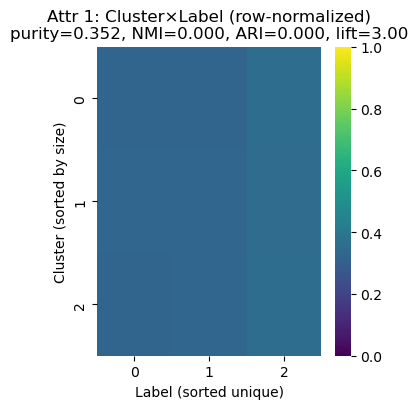

{'purity': np.float64(0.3523560419321646), 'NMI': np.float64(1.6848789460712766e-06), 'homogeneity': np.float64(1.6455298574276864e-06), 'completeness': np.float64(1.7261560253958326e-06), 'ARI': 2.1787638625251304e-05, 'P(same_label)': np.float64(0.33387557352073755), 'P(same_label|same_cluster)': np.float64(1.0015865681235643), 'lift': np.float64(2.9998797383072238)}


In [71]:
a = 0  # 보고 싶은 attribute 인덱스
metrics, cont, (cids, uniq_lab) = eval_corr_for_attribute(
    base_vector_npy, payloads[:, a], card=cards[a], seed=42, sample_for_plot=50, title_prefix=f"Attr {a+1}"
)
print(metrics)

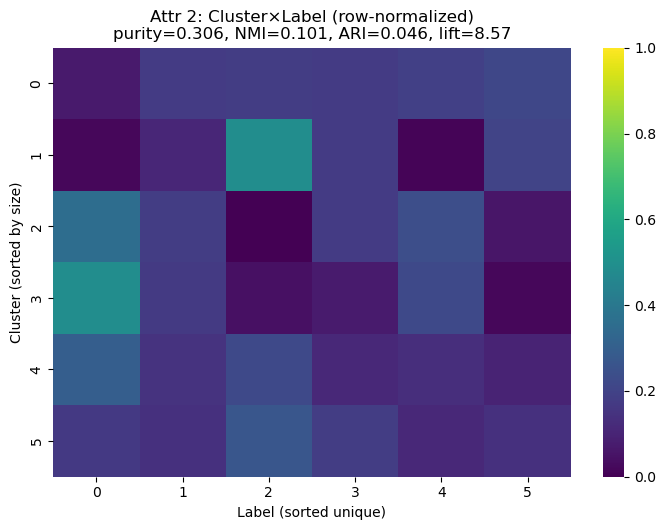

{'purity': np.float64(0.305517781427862), 'NMI': np.float64(0.10071851908735592), 'homogeneity': np.float64(0.09284763304861425), 'completeness': np.float64(0.11004747099034304), 'ARI': 0.04629524984844879, 'P(same_label)': np.float64(0.16834727363925295), 'P(same_label|same_cluster)': np.float64(1.4425224436722661), 'lift': np.float64(8.568730651111355)}


In [72]:
a = 1 # 보고 싶은 attribute 인덱스
metrics, cont, (cids, uniq_lab) = eval_corr_for_attribute(
    base_vector_npy, payloads[:, a], card=cards[a], seed=42, sample_for_plot=50, title_prefix=f"Attr {a+1}"
)
print(metrics)

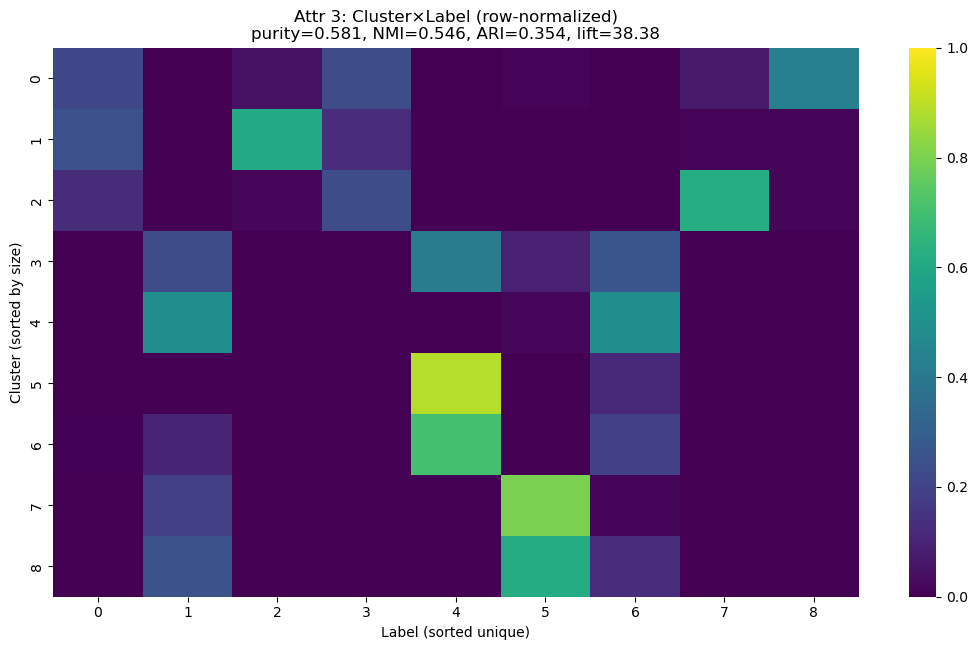

{'purity': np.float64(0.5808135177068264), 'NMI': np.float64(0.5456850354755491), 'homogeneity': np.float64(0.5361735136192344), 'completeness': np.float64(0.5555401137283311), 'ARI': 0.3542639076465427, 'P(same_label)': np.float64(0.11572007964330079), 'P(same_label|same_cluster)': np.float64(4.441302236238433), 'lift': np.float64(38.379702553697356)}


In [73]:
a = 2 # 보고 싶은 attribute 인덱스
metrics, cont, (cids, uniq_lab) = eval_corr_for_attribute(
    base_vector_npy, payloads[:, a], card=cards[a], seed=42, sample_for_plot=50, title_prefix=f"Attr {a+1}"
)
print(metrics)

In [74]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

try:
    import umap
    _HAS_UMAP = True
except Exception:
    _HAS_UMAP = False


def scatter_2d_by_label(
    X,                 # (N, D)
    labels,            # (N,)
    method="pca",      # "pca" | "umap"
    sample_max=50000,
    seed=42,
    point_size=2.0,
    alpha=0.8
):
    assert X.shape[0] == labels.shape[0]
    rng = np.random.default_rng(seed)

    # --- 1. 결측 제외 ---
    mask = (labels != -1)
    Xp = X[mask]
    yp = labels[mask]

    # --- 2. (선택) 샘플링 ---
    N = len(yp)
    if sample_max is not None and N > sample_max:
        idx = rng.choice(N, size=sample_max, replace=False)
        Xp = Xp[idx]
        yp = yp[idx]

    # --- 3. 2D 임베딩 ---
    if method.lower() == "umap":
        if not _HAS_UMAP:
            raise RuntimeError("umap-learn이 설치되어 있지 않습니다. pip install umap-learn")
        reducer = umap.UMAP(n_components=2, random_state=seed, n_neighbors=30, min_dist=0.1)
        Z = reducer.fit_transform(Xp)
    else:
        Z = PCA(n_components=2, random_state=seed).fit_transform(Xp)

    # --- 4. 색상 생성 ---
    uniq = np.unique(yp)
    n_colors = len(uniq)
    cmap = plt.cm.get_cmap("tab20" if n_colors <= 20 else "hsv", n_colors)
    colors = {lab: cmap(i) for i, lab in enumerate(uniq)}

    # --- 5. 시각화 ---
    plt.figure(figsize=(8, 7))
    for lab in uniq:
        m = (yp == lab)
        plt.scatter(
            Z[m, 0], Z[m, 1],
            s=point_size,
            c=[colors[lab]],
            label=str(lab),
            alpha=alpha,
            linewidths=0
        )

    plt.title(f"2D scatter by label ({method.upper()})  N={len(yp):,}")
    plt.xlabel("dim-1"); plt.ylabel("dim-2")

    if len(uniq) <= 25:
        plt.legend(markerscale=3, frameon=False, ncol=3)
    plt.tight_layout()
    plt.show()


/tmp/ipykernel_2567831/2728402782.py:48: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20" if n_colors <= 20 else "hsv", n_colors)


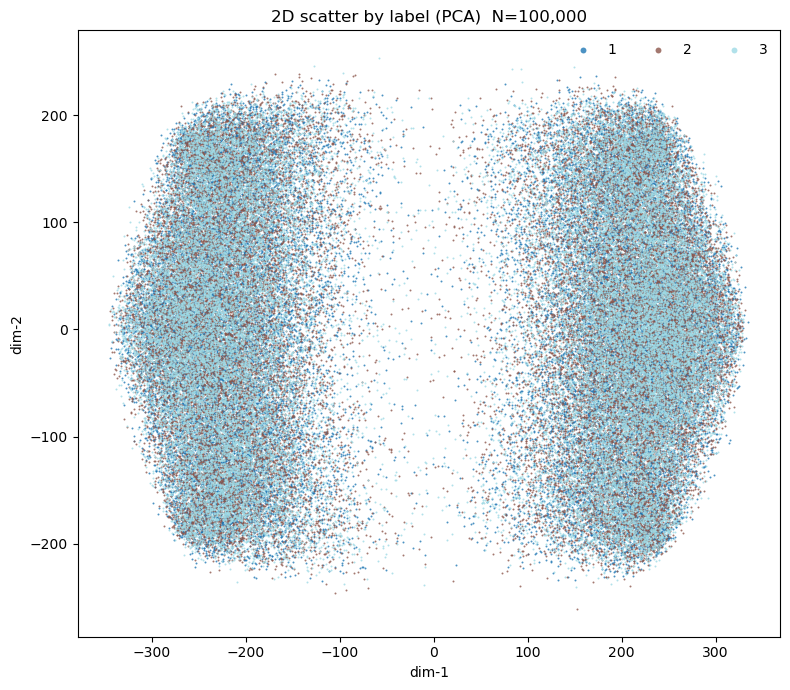

In [75]:
scatter_2d_by_label(base_vector_npy, payloads[:, 0], method="pca", sample_max=100000)

/tmp/ipykernel_2567831/2728402782.py:48: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20" if n_colors <= 20 else "hsv", n_colors)


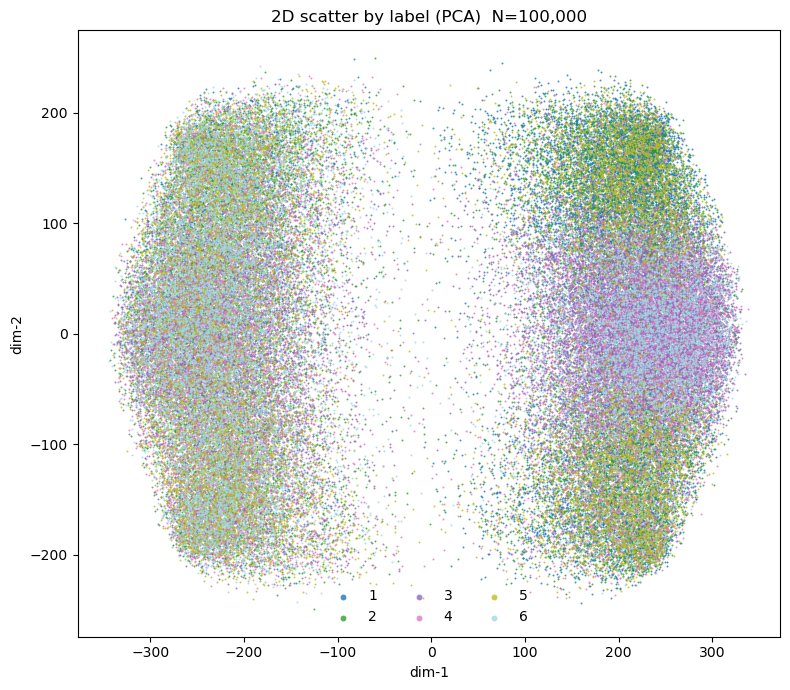

In [76]:
scatter_2d_by_label(base_vector_npy, payloads[:, 1], method="pca", sample_max=100000)

/tmp/ipykernel_2567831/2728402782.py:48: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20" if n_colors <= 20 else "hsv", n_colors)


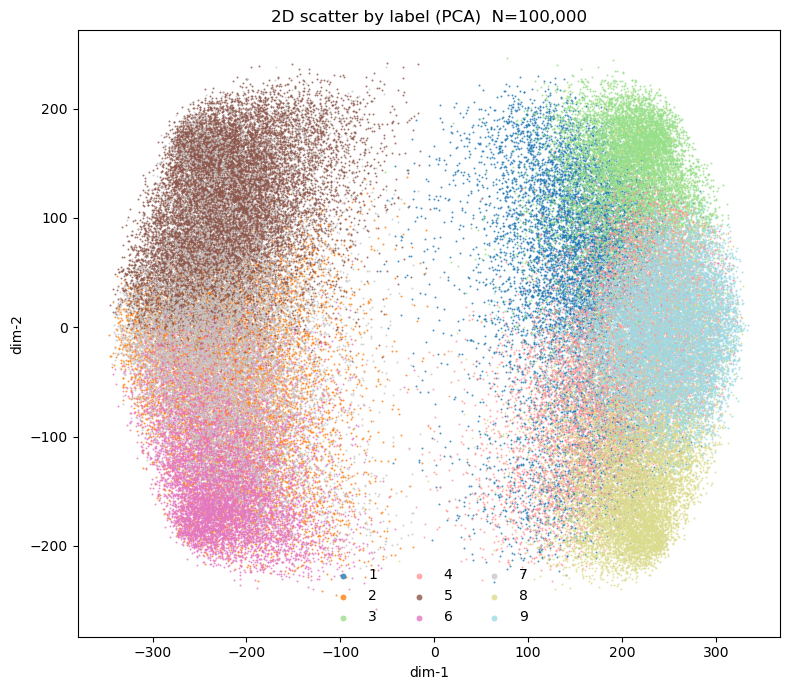

In [77]:
scatter_2d_by_label(base_vector_npy, payloads[:, 2], method="pca", sample_max=100000)